In [1]:
import sys, os, torch

print("Python:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("CWD:", os.getcwd())

Python: c:\Users\follo\anaconda3\envs\yolact\python.exe
CUDA available: True
CWD: e:\Education\debts\3 course 2 semester\Practice\yolact


c:\Users\follo\anaconda3\envs\yolact\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
from math import ceil

ann_path = r"E:\Education\debts\3 course 2 semester\Practice\Datasets\Lars\yolact_instance\annotations\instances_train.json"
batch_size = 4
max_iter = 120000

with open(ann_path, "r", encoding="utf-8") as f:
    data = json.load(f)

N = len(data["images"])
epoch_size = N // batch_size
num_epochs = ceil(max_iter / epoch_size)

print("train images:", N)
print("iters per epoch:", epoch_size)
print("epochs:", num_epochs)

train images: 2605
iters per epoch: 651
epochs: 185


In [3]:
import json
from pathlib import Path

ann_path = r"E:\Education\debts\3 course 2 semester\Practice\Datasets\Lars\yolact_instance\annotations\instances_train.json"

with open(ann_path, "r", encoding="utf-8") as f:
    data = json.load(f)

bad_boxes = 0
for ann in data["annotations"]:
    x, y, w, h = ann["bbox"]
    if w <= 1 or h <= 1:
        bad_boxes += 1

print("Very small or zero-size boxes:", bad_boxes)

Very small or zero-size boxes: 0


In [4]:
import sys
import subprocess
from pathlib import Path

PROJECT_DIR = Path(r"E:\Education\debts\3 course 2 semester\Practice\yolact")

BATCH_SIZE = 4
ITERS_PER_EPOCH = 651
SAVE_INTERVAL = ITERS_PER_EPOCH   # сохранять раз в эпоху

print("Python:", sys.executable)
print("Project dir:", PROJECT_DIR)
print("Batch size:", BATCH_SIZE)
print("Save interval:", SAVE_INTERVAL)
print("Validation every epoch: yes")
print("Autoscale: off")

cmd = [
    sys.executable,
    "train.py",
    "--config=lars_yolact_config",
    f"--batch_size={BATCH_SIZE}",
    "--no_autoscale",
    "--validation_epoch=1",
    f"--save_interval={SAVE_INTERVAL}",
]

proc = subprocess.Popen(
    cmd,
    cwd=str(PROJECT_DIR),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

for line in proc.stdout:
    print(line, end="")

proc.wait()
print("Return code:", proc.returncode)

Python: c:\Users\follo\anaconda3\envs\yolact\python.exe
Project dir: E:\Education\debts\3 course 2 semester\Practice\yolact
Batch size: 4
Save interval: 651
Validation every epoch: yes
Autoscale: off
Per-GPU batch size is less than the recommended limit for batch norm. Disabling batch norm.
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
c:\Users\follo\anaconda3\envs\yolact\lib\site-packages\torch\jit\_recursive.py:202: UserWarning: 'lat_layers' was found in ScriptModule constants,  but it is a non-constant submodule. Consider removing it.
  " but it is a non-constant {}. Consider removing it.".format(name, hint))
c:\Users\follo\anaconda3\envs\yolact\lib\site-packages\torch\jit\_recursive.py:202: UserWarning: 'pred_layers' was found in ScriptModule constants,  but it is a non-constant submodule. Consider removing it.
  " but it is a non-constant {}. Consider removing it

In [7]:
import sys
import subprocess
from pathlib import Path

PROJECT_DIR = Path(r"E:\Education\debts\3 course 2 semester\Practice\yolact")

MODEL_PATH = r"E:\Education\debts\3 course 2 semester\Practice\yolact\weights\lars_yolact_102_52080.pth"

# ОБА пути делаем относительными, без 'E:' и без двоеточий
INPUT_DIR_REL = r"..\Datasets\val"
OUTPUT_DIR_REL = r"val_preview_out_epoch3"

cmd = [
    sys.executable,
    "eval.py",
    f"--trained_model={MODEL_PATH}",
    "--config=lars_yolact_config",
    "--score_threshold=0.25",
    "--top_k=15",
    f"--images={INPUT_DIR_REL}:{OUTPUT_DIR_REL}",
]

print("Running:", " ".join(map(str, cmd)))

proc = subprocess.Popen(
    cmd,
    cwd=str(PROJECT_DIR),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

for line in proc.stdout:
    print(line, end="")

proc.wait()
print("Return code:", proc.returncode)
print("Saved results to:", PROJECT_DIR / OUTPUT_DIR_REL)

Running: c:\Users\follo\anaconda3\envs\yolact\python.exe eval.py --trained_model=E:\Education\debts\3 course 2 semester\Practice\yolact\weights\lars_yolact_102_52080.pth --config=lars_yolact_config --score_threshold=0.25 --top_k=15 --images=..\Datasets\val:val_preview_out_epoch3
Loading model...c:\Users\follo\anaconda3\envs\yolact\lib\site-packages\torch\jit\_recursive.py:202: UserWarning: 'lat_layers' was found in ScriptModule constants,  but it is a non-constant submodule. Consider removing it.
  " but it is a non-constant {}. Consider removing it.".format(name, hint))
c:\Users\follo\anaconda3\envs\yolact\lib\site-packages\torch\jit\_recursive.py:202: UserWarning: 'pred_layers' was found in ScriptModule constants,  but it is a non-constant submodule. Consider removing it.
  " but it is a non-constant {}. Consider removing it.".format(name, hint))
c:\Users\follo\anaconda3\envs\yolact\lib\site-packages\torch\jit\_recursive.py:202: UserWarning: 'downsample_layers' was found in ScriptMod

Train rows: 52080
Val rows: 103


,epoch,iter,lr,elapsed,B,C,M,S,T
0,0,0,0.000100,11.132238,14.25439,18.09058,14.97317,6.76321,54.08135
1,0,1,0.000101,1.475816,14.30006,13.50156,10.36219,5.68845,43.85226
2,0,2,0.000102,1.388720,8.02428,11.51151,9.00607,5.28466,33.82652
3,0,3,0.000102,0.912009,8.23782,11.04040,7.98514,5.10827,32.37162
4,0,4,0.000103,0.430896,7.91400,10.82989,11.64755,4.75559,35.14703


,epoch,iter,elapsed,box_all,box_50,box_55,box_60,box_65,box_70,box_75,...,mask_50,mask_55,mask_60,mask_65,mask_70,mask_75,mask_80,mask_85,mask_90,mask_95
0,1,1016,53.809505,0.03,0.11,0.07,0.05,0.04,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0
1,2,1524,42.747161,0.14,0.61,0.28,0.22,0.13,0.10,0.03,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0
2,3,2032,32.071873,0.27,0.86,0.65,0.45,0.30,0.21,0.13,...,0.89,0.62,0.46,0.24,0.09,0.03,0.01,0.0,0.0,0.0
3,4,2540,32.557020,0.01,0.05,0.03,0.02,0.01,0.01,0.01,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0
4,5,3048,34.646316,0.08,0.28,0.19,0.15,0.08,0.03,0.02,...,0.18,0.13,0.08,0.04,0.02,0.01,0.00,0.0,0.0,0.0


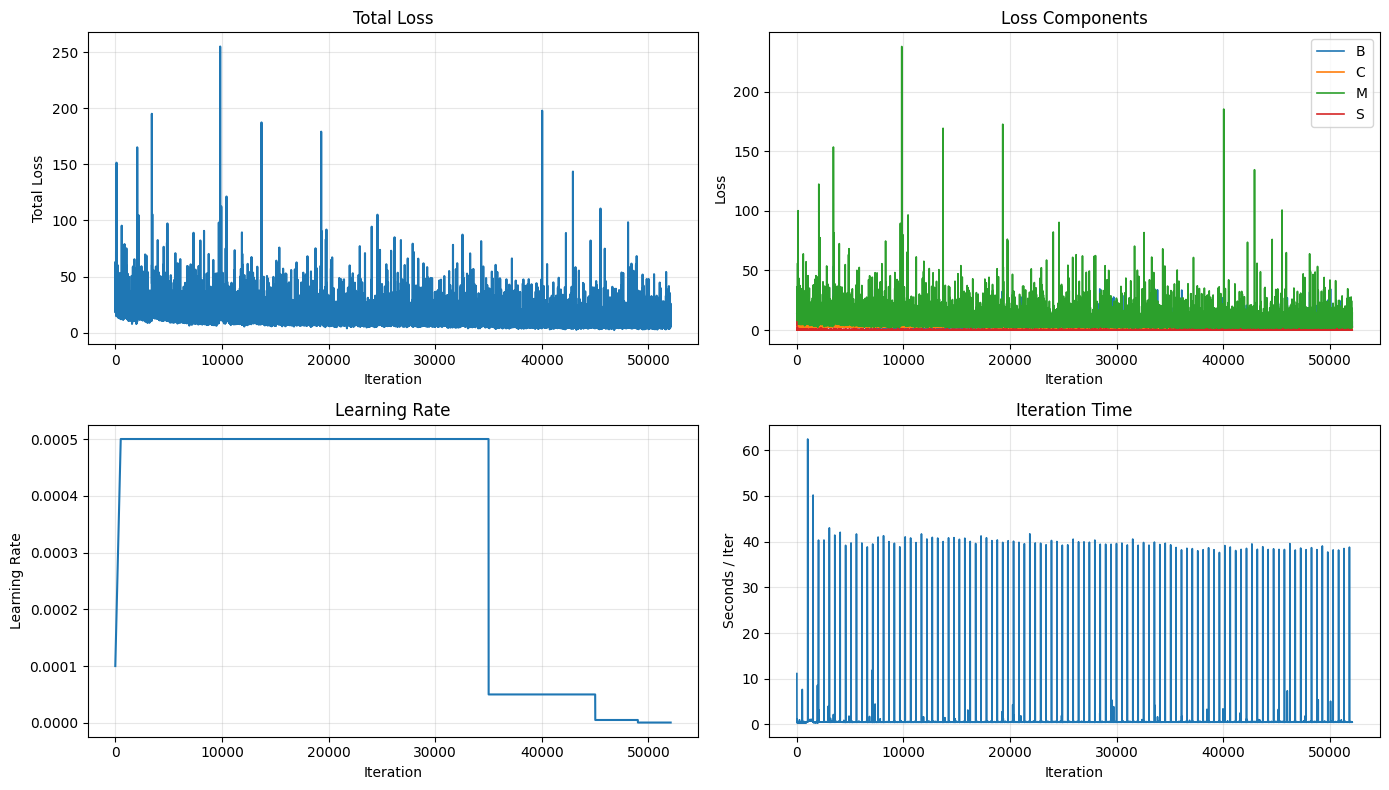

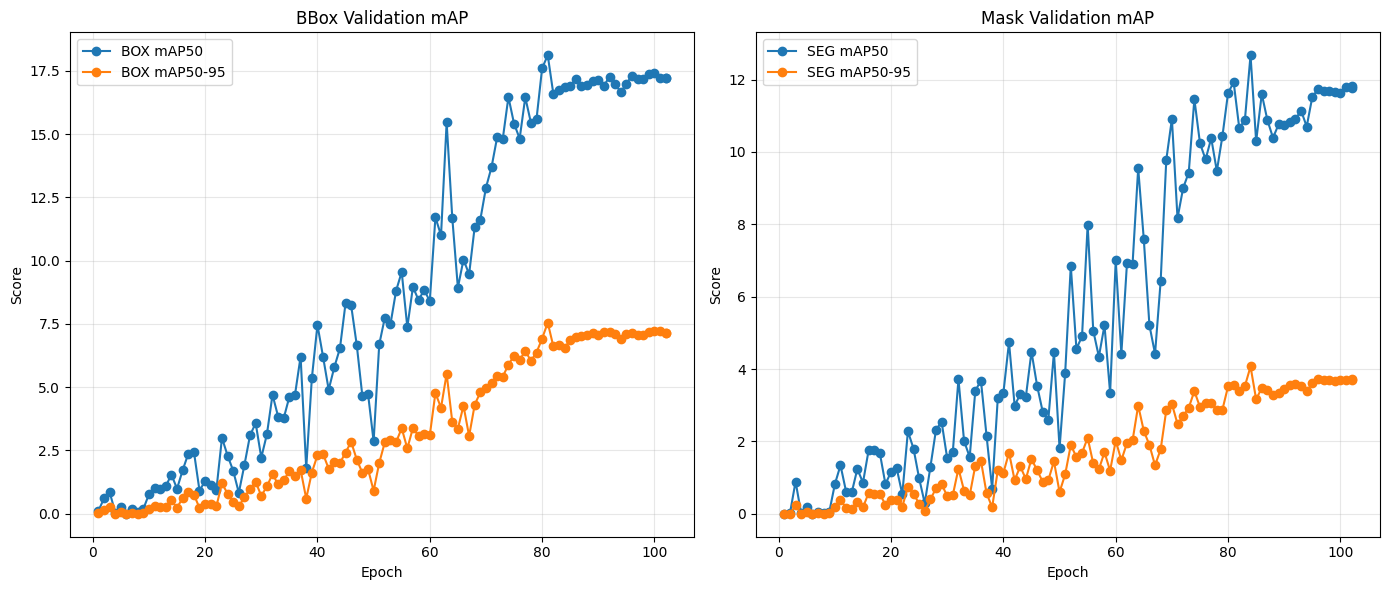

,epoch,iter,BOX_mAP50,BOX_mAP50_95,SEG_mAP50,SEG_mAP50_95
0,1,1016,0.11,0.03,0.00,0.00
1,2,1524,0.61,0.14,0.01,0.00
2,3,2032,0.86,0.27,0.89,0.23
3,4,2540,0.05,0.01,0.01,0.00
4,5,3048,0.28,0.08,0.18,0.05
...,...,...,...,...,...,...
98,99,50800,17.38,7.19,11.65,3.68
99,100,51308,17.39,7.20,11.64,3.69
100,101,51816,17.23,7.20,11.80,3.71
101,102,52080,17.23,7.15,11.82,3.72


In [11]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ПУТЬ К ЛОГУ
LOG_PATH = Path(r"E:\Education\debts\3 course 2 semester\Practice\yolact\logs\lars_yolact.log")
# Если хочешь протестировать на paste.txt:
# LOG_PATH = Path(r"E:\Education\debts\3 course 2 semester\Practice\paste.txt")

train_rows = []
val_rows = []

with LOG_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        # Берём только JSON-строки
        if not line.startswith("{"):
            continue

        try:
            obj = json.loads(line)
        except Exception:
            continue

        rec_type = obj.get("type")
        data = obj.get("data", {})

        if rec_type == "train":
            loss = data.get("loss", {})
            train_rows.append({
                "epoch": data.get("epoch"),
                "iter": data.get("iter"),
                "lr": data.get("lr"),
                "elapsed": data.get("elapsed"),
                "B": loss.get("B"),
                "C": loss.get("C"),
                "M": loss.get("M"),
                "S": loss.get("S"),
                "T": loss.get("T"),
            })

        elif rec_type == "val":
            box = data.get("box", {})
            mask = data.get("mask", {})
            val_rows.append({
                "epoch": data.get("epoch"),
                "iter": data.get("iter"),
                "elapsed": data.get("elapsed"),
                "box_all": box.get("all"),   # mAP50-95 bbox
                "box_50": box.get("50"),     # mAP50 bbox
                "box_55": box.get("55"),
                "box_60": box.get("60"),
                "box_65": box.get("65"),
                "box_70": box.get("70"),
                "box_75": box.get("75"),
                "box_80": box.get("80"),
                "box_85": box.get("85"),
                "box_90": box.get("90"),
                "box_95": box.get("95"),
                "mask_all": mask.get("all"), # mAP50-95 mask
                "mask_50": mask.get("50"),   # mAP50 mask
                "mask_55": mask.get("55"),
                "mask_60": mask.get("60"),
                "mask_65": mask.get("65"),
                "mask_70": mask.get("70"),
                "mask_75": mask.get("75"),
                "mask_80": mask.get("80"),
                "mask_85": mask.get("85"),
                "mask_90": mask.get("90"),
                "mask_95": mask.get("95"),
            })

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))

display(train_df.head())
display(val_df.head())

# Уберём inf / nan из train loss, чтобы графики не ломались
for col in ["B", "C", "M", "S", "T"]:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
        train_df.loc[~np.isfinite(train_df[col]), col] = np.nan

# ---- ГРАФИКИ TRAIN LOSS ----
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(train_df["iter"], train_df["T"], label="T", linewidth=1.5)
plt.xlabel("Iteration")
plt.ylabel("Total Loss")
plt.title("Total Loss")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
for col in ["B", "C", "M", "S"]:
    if col in train_df.columns:
        plt.plot(train_df["iter"], train_df[col], label=col, linewidth=1.2)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Components")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
if "lr" in train_df.columns:
    plt.plot(train_df["iter"], train_df["lr"], linewidth=1.5)
    plt.xlabel("Iteration")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate")
    plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
if "elapsed" in train_df.columns:
    plt.plot(train_df["iter"], train_df["elapsed"], linewidth=1.2)
    plt.xlabel("Iteration")
    plt.ylabel("Seconds / Iter")
    plt.title("Iteration Time")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- ГРАФИКИ VAL mAP ----
if len(val_df) > 0:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(val_df["epoch"], val_df["box_50"], marker="o", label="BOX mAP50")
    plt.plot(val_df["epoch"], val_df["box_all"], marker="o", label="BOX mAP50-95")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("BBox Validation mAP")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(val_df["epoch"], val_df["mask_50"], marker="o", label="SEG mAP50")
    plt.plot(val_df["epoch"], val_df["mask_all"], marker="o", label="SEG mAP50-95")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Mask Validation mAP")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Табличка как в YOLO-стиле
    summary_df = val_df[["epoch", "iter", "box_50", "box_all", "mask_50", "mask_all"]].copy()
    summary_df = summary_df.rename(columns={
        "box_50": "BOX_mAP50",
        "box_all": "BOX_mAP50_95",
        "mask_50": "SEG_mAP50",
        "mask_all": "SEG_mAP50_95",
    })
    display(summary_df)
else:
    print("В логе пока нет val-записей.")

In [6]:
from yolact import Yolact
from data.config import lars_yolact_config

net = Yolact(lars_yolact_config)
net.load_weights('weights/lars_yolact_10_5000.pth')
net.eval()

TypeError: __init__() takes 1 positional argument but 2 were given